#Performs the following experiments:

## A) SiT-S/8  × CheXpert — Standard VAE

Trains **SiT-S/8** on CheXpert using only the diffusion loss χωρίς REPA alignment, χωρίς encoder.

- `--enc-type None`:  δεν φορτώνεται κανένας visual encoder
- `--proj-coeff 0.0`: total loss = μόνο denoising loss
- `--vae sd-vae-ft-mse`: standard Stable Diffusion VAE

Resulted FID Score: 216.5186

## B) SiT-S/8  × CheXpert — MedVAE
- `--enc-type None`
- `--proj-coeff 0.0`
- `--vae-type medvae`: MedVAE (medical diffusion VAE)

Resulted FID Score: 214.8266

## C) REPA × CheXpert × MedDINOv3
- `--enc-type meddinov3-vit-b`: pretrained medical encoder
- `--proj-coeff 0.5`
- `--vae-type medvae`

Resulted FID Score: 204.3348


## 1. Install dependencies

In [1]:
!pip install -q accelerate diffusers timm einops pandas kaggle medvae

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.7/100.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 111.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 126.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 130.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
RESULTS_DIR = '/content/drive/MyDrive/sit-chexpert-results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print('Drive mounted. Results will be saved to:', RESULTS_DIR)

Mounted at /content/drive
Drive mounted. Results will be saved to: /content/drive/MyDrive/sit-chexpert-results


## 2. Clone REPA fork

In [3]:
%%bash
if [ ! -d "/content/REPA" ]; then
    git clone https://github.com/nikiboura/REPA.git /content/REPA
fi
cd /content/REPA && git pull
echo "REPA ready. Commit: $(git rev-parse --short HEAD)"

Already up to date.
REPA ready. Commit: fbd12aa


Cloning into '/content/REPA'...


## 3. Prepare CheXpert


In [ ]:
"""
#sanity check
!python /content/REPA/dataset_preparation_scripts/prepare_chexpert.py \
      --chexpert-root /content/chexpert \
      --out-dir /content/data/chexpert_256 \
      --resolution 256 \
      --max-samples 33 \
      --vae-type sd \
      --kaggle-json /content/REPA/dataset_preparation_scripts/kaggle.json
"""

'\n#sanity check\n!python /content/REPA/dataset_preparation_scripts/prepare_chexpert.py       --chexpert-root /content/chexpert       --out-dir /content/data/chexpert_256       --resolution 256       --max-samples 33       --vae-type sd       --kaggle-json /content/REPA/dataset_preparation_scripts/kaggle.json\n'

#### For A - SiT/S-8 with standard VAE
  - using - `--vae-type: sd`

In [9]:
# SiT/S-8 with standard VAE
!python /content/REPA/dataset_preparation_scripts/prepare_chexpert.py \
      --chexpert-root /content/chexpert \
      --out-dir /content/data/chexpert_256_sdvae \
      --resolution 256 \
      --max-samples 80000 \
      --vae-type sd \
      --kaggle-json /content/REPA/dataset_preparation_scripts/kaggle.json

/content/REPA/dataset_preparation_scripts/prepare_chexpert.py:14: SyntaxWarning: invalid escape sequence '\ '
  --data-root /content/chexpert \              # raw dataset saved here
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Dataset URL: https://www.kaggle.com/datasets/ashery/chexpert
License(s): CC0-1.0
Resuming from 5847908352 bytes (5648222157 bytes left)...
100% 10.7G/10.7G [05:08<00:00, 18.3MB/s]

Download complete.
Using device: cuda
Loading VAE...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
diffusion_pytorch_model.

#### For B,C - SiT/S-8 with MedVAE
 - using - `--vae-type: medvae`

In [10]:
# SiT/S-8 with MedVAE
!python /content/REPA/dataset_preparation_scripts/prepare_chexpert.py \
      --chexpert-root /content/chexpert \
      --out-dir /content/data/chexpert_256_medvae \
      --resolution 256 \
      --max-samples 80000 \
      --vae-type medvae \
      --kaggle-json /content/REPA/dataset_preparation_scripts/kaggle.json

/content/REPA/dataset_preparation_scripts/prepare_chexpert.py:14: SyntaxWarning: invalid escape sequence '\ '
  --data-root /content/chexpert \              # raw dataset saved here
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
CheXpert already downloaded, skipping.
Using device: cuda
Loading VAE...
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
medvae_8x4.yaml: 1.14kB [00:00, 3.75MB/s]
model_weights/vae_8x_4c_2D.ckpt: 100% 338M/338M [00:11<00:00, 30.7MB/s]
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention o

In [ ]:
!git -C /content/REPA pull

## 4. Train


In [ ]:
"""
#sanity check
!python /content/REPA/train.py \
  --exp-name sit-s8-chexpert-sdvae \
  --output-dir /content/drive/MyDrive/repa_results \
  --report-to none \
  --model SiT-S/8 \
  --num-classes 2 \
  --enc-type None \
  --proj-coeff 0.0 \
  --vae-type sd \
  --data-dir /content/data/chexpert_256 \
  --resolution 256 \
  --batch-size 32 \
  --num-workers 2 \
  --epochs 200 \
  --learning-rate 1e-4 \
  --mixed-precision fp16 \
  --cfg-prob 0.1 \
  --path-type linear \
  --max-train-steps 1 \
  --checkpointing-steps 1 \
  --sampling-steps 99999999 \
  --teacher-ckpt /content/drive/MyDrive/last.pt
"""

'\n#sanity check\n!python /content/REPA/train.py   --exp-name sit-s8-chexpert-sdvae   --output-dir /content/drive/MyDrive/repa_results   --report-to none   --model SiT-S/8   --num-classes 2   --enc-type None   --proj-coeff 0.0   --vae-type sd   --data-dir /content/data/chexpert_256   --resolution 256   --batch-size 32   --num-workers 2   --epochs 200   --learning-rate 1e-4   --mixed-precision fp16   --cfg-prob 0.1   --path-type linear   --max-train-steps 1   --checkpointing-steps 1   --sampling-steps 99999999   --teacher-ckpt /content/drive/MyDrive/last.pt \n'

#### A) SiT/S-8 with standard VAE

In [ ]:
# A
!python /content/REPA/train.py \
  --exp-name sit-s8-chexpert-sdvae \
  --output-dir /content/drive/MyDrive/repa_results \
  --report-to none \
  --model SiT-S/8 \
  --num-classes 2 \
  --enc-type None \
  --proj-coeff 0.0 \
  --vae-type sd \
  --data-dir /content/data/chexpert_256_sdvae \
  --resolution 256 \
  --batch-size 32 \
  --num-workers 2 \
  --epochs 200 \
  --learning-rate 1e-4 \
  --mixed-precision fp16 \
  --cfg-prob 0.1 \
  --path-type linear \
  --max-train-steps 400000 \
  --checkpointing-steps 400000 \
  --sampling-steps 99999999 \
  --teacher-ckpt /content/drive/MyDrive/last.pt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
encoder-depth auto-computed: 3/12 (28% of model depth)
Weight selection: 127 layers initialized from teacher
Skipped (kept default init): 5 layers
Encoder block mapping (student→teacher): [(0, 0), (1, 1), (2, 2)]
Decoder block mapping (student→teacher): [(3, 3), (4, 6), (5, 9), (6, 12), (7, 15), (8, 18), (9, 21), (10, 24), (11, 27)]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Steps: 100% 400000/400000 [7:07:22<00:00, 15.60it/s, grad_norm=0.12, loss=0.741, proj_loss=0]


#### B) SiT/S-8 with medVAE

In [ ]:
!git -C /content/REPA pull
# B
!python /content/REPA/train.py \
  --exp-name sit-s8-chexpert-medvae \
  --output-dir /content/drive/MyDrive/repa_results \
  --report-to none \
  --model SiT-S/8 \
  --num-classes 2 \
  --enc-type None \
  --proj-coeff 0.0 \
  --vae-type medvae \
  --data-dir /content/data/chexpert_256_medvae \
  --resolution 256 \
  --batch-size 32 \
  --num-workers 2 \
  --epochs 200 \
  --learning-rate 1e-4 \
  --mixed-precision fp16 \
  --cfg-prob 0.1 \
  --path-type linear \
  --max-train-steps 400000 \
  --checkpointing-steps 400000 \
  --sampling-steps 99999999 \
  --teacher-ckpt /content/drive/MyDrive/last.pt

#### C) SiT/S-8 with medVAE & REPA allignment

In [ ]:
# C
!python /content/REPA/train.py \
  --exp-name sit-s8-chexpert-medvae-repa \
  --output-dir /content/drive/MyDrive/repa_results \
  --report-to none \
  --model SiT-S/8 \
  --num-classes 2 \
  --enc-type meddinov3-vit-b \
  --proj-coeff 0.5 \
  --vae-type medvae \
  --data-dir /content/data/chexpert_256_medvae \
  --resolution 256 \
  --batch-size 32 \
  --num-workers 2 \
  --epochs 200 \
  --learning-rate 1e-4 \
  --mixed-precision fp16 \
  --cfg-prob 0.1 \
  --path-type linear \
  --max-train-steps 400000 \
  --checkpointing-steps 400000 \
  --sampling-steps 99999999 \
  --teacher-ckpt /content/drive/MyDrive/last.pt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
encoder-depth auto-computed: 3/12 (28% of model depth)
MedDINOv3 not found, downloading from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/nikiboura/meddinov3-minimal
License(s): unknown
100% 304M/304M [00:20<00:00, 15.2MB/s]

MedDINOv3 downloaded.
Weight selection: 127 layers initialized from teacher
Skipped (kept default init): 11 layers
Encoder block mapping (student→teacher): [(0, 0), (1, 1), (2, 2)]
Decoder block mapping (student→teacher): [(3, 3), (4, 6), (5, 9), (6, 12), (7, 15), (8, 18), (9, 21), (10, 24), (11, 27)]
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the 

## 5. Generate samples


In [ ]:
#sanity check
"""
!torchrun --nproc_per_node=1 --master_port=29501 /content/REPA/generate.py \
  --model SiT-S/8 \
  --ckpt /content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/checkpoints/0000001.pt \
  --sample-dir /content/drive/MyDrive/repa_results/samples \
  --num-classes 2 \
  --per-proc-batch-size 16 \
  --num-fid-samples 20 \
  --path-type linear \
  --mode ode \
  --num-steps 50 \
  --cfg-scale 1.5 \
  --resolution 256 \
  --vae mse
"""

### A) SiT/S-8 with standard VAE

In [6]:
!torchrun --nproc_per_node=1 --master_port=29501 /content/REPA/generate.py \
  --model SiT-S/8 \
  --ckpt $(ls /content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/checkpoints/*.pt | sort |tail -1) \
  --sample-dir /content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/samples \
  --num-classes 2 \
  --per-proc-batch-size 16 \
  --num-fid-samples 5000 \
  --path-type linear \
  --mode ode \
  --num-steps 50 \
  --cfg-scale 1.5 \
  --resolution 256 \
  --vae mse

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
encoder-depth auto-computed: 3/12 (28% of model depth)
Starting rank=0, seed=0, world_size=1.
Missing keys (will use random init, e.g. projectors not in EMA): ['projectors.0.0.weight', 'projectors.0.0.bias', 'projectors.0.2.weight', 'projectors.0.2.bias', 'projectors.0.4.weight', 'projectors.0.4.bias', 'projectors.1.0.weight', 'projectors.1.0.bias', 'projectors.1.2.weight', 'projectors.1.2.bias', 'projectors.1.4.weight', 'projectors.1.4.bias']
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warning

#### B) SiT/S-8 with medVAE

In [ ]:
!torchrun --nproc_per_node=1 --master_port=29501 /content/REPA/generate.py \
  --model SiT-S/8 \
  --ckpt $(ls /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/checkpoints/*.pt | sort |tail -1) \
  --sample-dir /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/samples \
  --num-classes 2 \
  --per-proc-batch-size 16 \
  --num-fid-samples 5000 \
  --path-type linear \
  --mode ode \
  --num-steps 50 \
  --cfg-scale 1.5 \
  --resolution 256 \
  --vae medvae

#### C) SiT/S-8 with medVAE & REPA allignment

In [ ]:
!torchrun --nproc_per_node=1 --master_port=29501 /content/REPA/generate.py \
  --model SiT-S/8 \
  --ckpt $(ls /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/checkpoints/*.pt | sort |tail -1) \
  --sample-dir /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/samples \
  --num-classes 2 \
  --per-proc-batch-size 16 \
  --projector-embed-dims 768 \
  --num-fid-samples 5000 \
  --path-type linear \
  --mode ode \
  --num-steps 50 \
  --cfg-scale 1.5 \
  --resolution 256 \
  --vae medvae

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
encoder-depth auto-computed: 3/12 (28% of model depth)
Starting rank=0, seed=0, world_size=1.
<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
making attention of type 'vanilla' with 512 in_channels
Restored from /root/.cache/huggingface/hub/models--stanfordmimi--MedVAE/snapshots/8040c5ccb7a51eff6b4cef513c7f20bd1bda983d/model_weights/vae_8x_4c_2D.ckpt with 0 missing and 0 unexpected keys
Saving .png samples at /content/drive/MyDrive

## 8. Show generated images

A) SiT/S-8 with sd VAE
Total generated: 5000


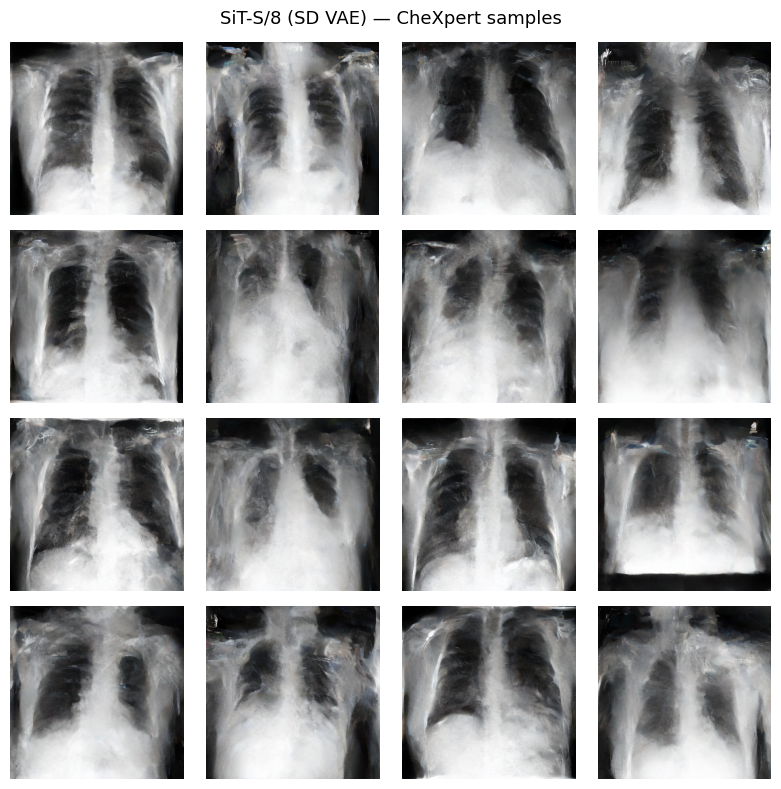

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# A
print("A) SiT/S-8 with sd VAE")
npz_files = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/samples/**/*.npz', recursive=True))
data = np.load(npz_files[-1])
imgs = data[data.files[0]]
print(f'Total generated: {len(imgs)}')

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].astype('uint8'), cmap='gray')
    ax.axis('off')
plt.suptitle('SiT-S/8 (SD VAE) — CheXpert samples', fontsize=13)
plt.tight_layout()
plt.show()

B) SiT/S-8 with medVAE
Total generated: 5000


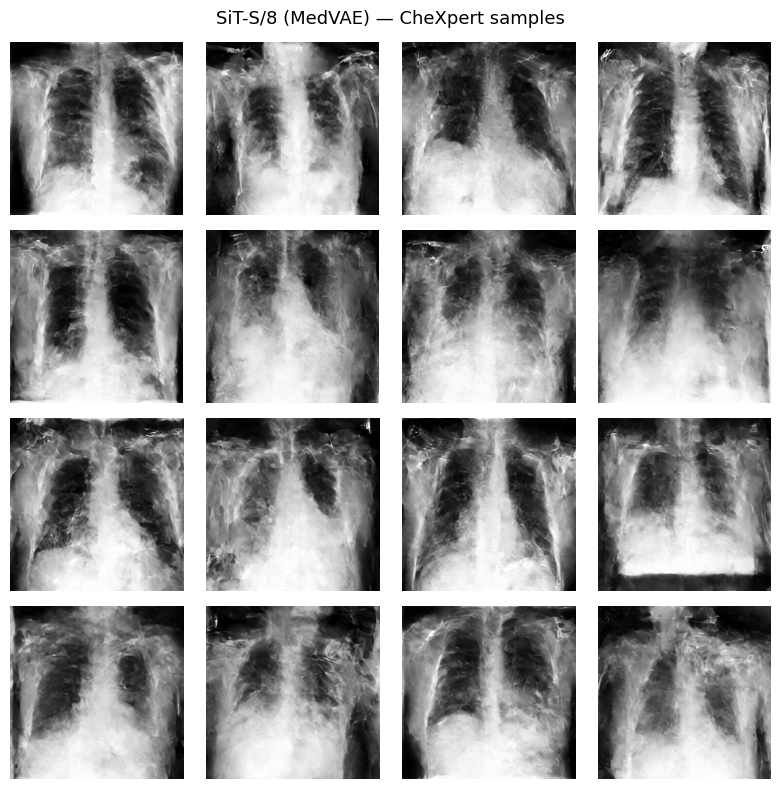

In [12]:
# B
print("B) SiT/S-8 with medVAE")
npz_files = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/samples/**/*.npz', recursive=True))
data = np.load(npz_files[-1])
imgs = data[data.files[0]]
print(f'Total generated: {len(imgs)}')

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].astype('uint8'), cmap='gray')
    ax.axis('off')
plt.suptitle('SiT-S/8 (MedVAE) — CheXpert samples', fontsize=13)
plt.tight_layout()
plt.show()

C) SiT/S-8 with medVAE & REPA
Total generated: 5000


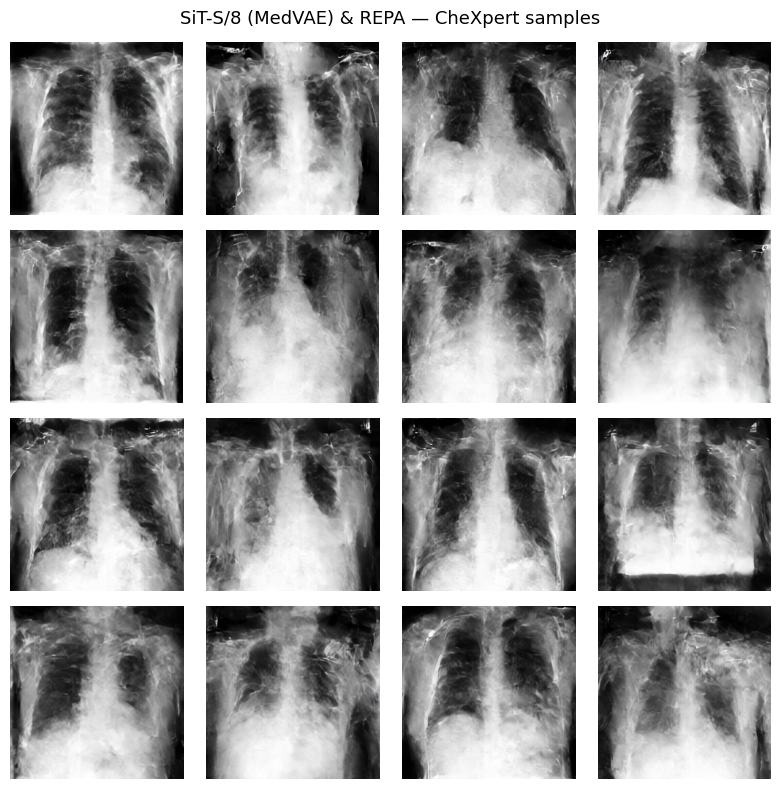

In [13]:
# C
print("C) SiT/S-8 with medVAE & REPA")
npz_files = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/samples/**/*.npz', recursive=True))
data = np.load(npz_files[-1])
imgs = data[data.files[0]]
print(f'Total generated: {len(imgs)}')

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].astype('uint8'), cmap='gray')
    ax.axis('off')
plt.suptitle('SiT-S/8 (MedVAE) & REPA — CheXpert samples', fontsize=13)
plt.tight_layout()
plt.show()

## 9. Compute FID score

In [14]:
# A
import subprocess, glob, os

subprocess.run(['pip', 'install', '-q', 'torch-fidelity'], check=True)

subdirs = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/samples/*/'))
gen_dir = subdirs[-1]
print(f'Generated: {gen_dir}')

result = subprocess.run([
      'fidelity', '--gpu', '0', '--fid',
      '--samples-find-deep',
      '--input1', gen_dir,
      '--input2', '/content/data/chexpert_256_sdvae/images/train',
], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Generated: /content/drive/MyDrive/repa_results/sit-s8-chexpert-sdvae/samples/SiT-S-8-0400000-size-256-vae-mse-cfg-1.5-seed-0-ode/
frechet_inception_distance: 216.5186

Creating feature extractor "inception-v3-compat" with features ['2048']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth

  0%|          | 0.00/91.2M [00:00<?, ?B/s]
 11%|█         | 10.1M/91.2M [00:00<00:02, 34.7MB/s]
 22%|██▏       | 20.1M/91.2M [00:00<00:01, 37.8MB/s]
 33%|███▎      | 30.1M/91.2M [00:00<00:01, 40.0MB/s]
 44%|████▍     | 40.1M/91.2M [00:01<00:01, 38.7MB/s]
 55%|█████▍    | 50.1M/91.2M [00:01<00:01, 39.7MB/s]
 66%|██████▌   | 60.1M/91.2M [00:01<00:00, 39.6MB/s]
 77%|███████▋  | 70.1M/91.2M [00:01<00:00, 40.6MB/s]
 88%|████████▊ | 80.1M/91.2M [00:02<00:00, 40.4MB/s]
 99%|█████████▉| 90.1M/91.2M [00:02<00:00, 40.5MB/s]
100%|██████████| 91.2M/91.2M [00:02

In [15]:
# B
subdirs = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/samples/*/'))
gen_dir = subdirs[-1]
print(f'Generated: {gen_dir}')

result = subprocess.run([
      'fidelity', '--gpu', '0', '--fid',
      '--samples-find-deep',
      '--input1', gen_dir,
      '--input2', '/content/data/chexpert_256_medvae/images/train',
], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Generated: /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/samples/SiT-S-8-0400000-size-256-vae-medvae-cfg-1.5-seed-0-ode/
frechet_inception_distance: 214.8266

Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting statistics from input 1
Looking for samples recursively in "/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae/samples/SiT-S-8-0400000-size-256-vae-medvae-cfg-1.5-seed-0-ode/" with extensions png,jpg,jpeg
Found 5008 samples

Processing samples: 100%|█████████▉| 4992/5008 [02:24<00:00, 412.60samples/s]
                                                                             
Processing samples
Extracting statistics from input 2
Looking for samples recursively in "/content/data/chexpert_256_medvae/images/train" with extensions png,jpg,jpeg
Found 80000 samples

Processing samples: 100%|██████████| 80000/80000 [02:13<00:00, 598.85samples/s]
                                                                               
Processi

In [16]:
# C
subdirs = sorted(glob.glob('/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/samples/*/'))
gen_dir = subdirs[-1]
print(f'Generated: {gen_dir}')

result = subprocess.run([
      'fidelity', '--gpu', '0', '--fid',
      '--samples-find-deep',
      '--input1', gen_dir,
      '--input2', '/content/data/chexpert_256_medvae/images/train',
], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

Generated: /content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/samples/SiT-S-8-0400000-size-256-vae-medvae-cfg-1.5-seed-0-ode/
frechet_inception_distance: 204.3348

Creating feature extractor "inception-v3-compat" with features ['2048']
Extracting statistics from input 1
Looking for samples recursively in "/content/drive/MyDrive/repa_results/sit-s8-chexpert-medvae-repa/samples/SiT-S-8-0400000-size-256-vae-medvae-cfg-1.5-seed-0-ode/" with extensions png,jpg,jpeg
Found 5008 samples

Processing samples: 100%|█████████▉| 4992/5008 [02:16<00:00, 570.91samples/s]
                                                                             
Processing samples
Extracting statistics from input 2
Looking for samples recursively in "/content/data/chexpert_256_medvae/images/train" with extensions png,jpg,jpeg
Found 80000 samples

Processing samples: 100%|██████████| 80000/80000 [02:13<00:00, 602.32samples/s]
                                                                              